In [1]:
! pip install networkx
! pip install matplotlib

node degree clustering
0 5 0.6
1 5 0.1
2 5 0.3
3 5 0.4
4 4 0.3333333333333333
5 5 0.1
6 3 0
7 2 1.0
8 6 0.2
9 3 1.0
10 0 0
11 1 0
12 5 0.2
13 7 0.14285714285714285
14 5 0.2
15 5 0.4
16 3 0.3333333333333333
17 4 0.16666666666666666
18 1 0
19 6 0.3333333333333333

the adjacency list
0 3 9 8 13 19
1 4 3 17 6 7
2 4 15 14 16 13
3 9 13 19
4 7 15
5 19 6 12 17 13
6 14
7
8 13 19 15 11 12
9 19
10
11
12 14 16 15
13 16 18
14 15 17
15
16
17 19
18
19


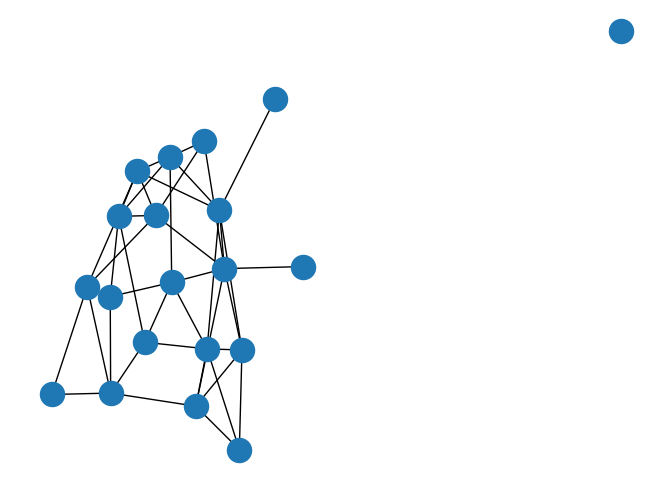

In [57]:
import matplotlib.pyplot as plt
import networkx as nx

n = 20  # 10 nodes
m = 40  # 20 edges
seed = 20160  # seed random number generators for reproducibility

# Use seed for reproducibility
# G = nx.gnm_random_graph(n, m, seed=seed)

G = nx.gnm_random_graph(n, m)

# some properties
print("node degree clustering")
for v in nx.nodes(G):
    print(f"{v} {nx.degree(G, v)} {nx.clustering(G, v)}")

print()
print("the adjacency list")
for line in nx.generate_adjlist(G):
    print(line)

pos = nx.spring_layout(G, seed=seed)  # Seed for reproducible layout
nx.draw(G, pos=pos)
plt.show()

In [58]:
def coloring_conflicts (G, coloring):
    conflicts = 0
    # Use the edge set to check for conflicts
    for u, v in G.edges():
        # print(f"edge ({u}, {v}) has colors {coloring[u]} and {coloring[v]}")
        if coloring[u] == coloring[v]:
            conflicts += 1
    return conflicts

## Testing out coloring using built in greedy algorithm

In [59]:
def graph_coloring(G):
    # Use a greedy coloring algorithm
    coloring = nx.coloring.greedy_color(G, strategy='largest_first')
    return coloring

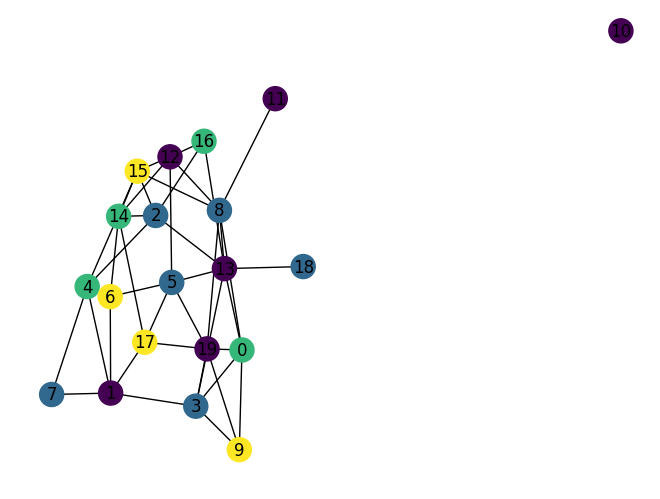

In [60]:
coloring = graph_coloring(G)
node_colors = [coloring[node] for node in G.nodes()]
nx.draw(G, pos=pos, node_color=node_colors, with_labels=True)
plt.show() 

### Check for conflicts

In [61]:
conflicts = coloring_conflicts(G, coloring)
conflicts

0

## Randomly assigning colors

In [62]:

import random
      
def random_coloring(G):
    coloring = {}
    for node in G.nodes():
        coloring[node] = random.randint(0, n-1)  # Random color from 0 to n-1
    return coloring

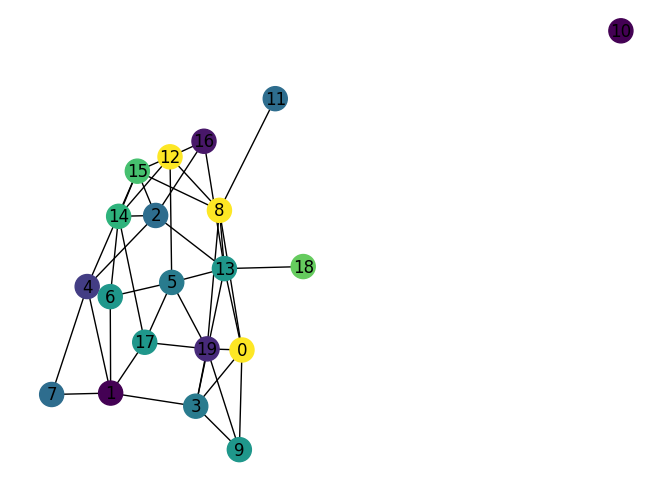

In [63]:
coloring = random_coloring(G)
node_colors = [coloring[node] for node in G.nodes()]
nx.draw(G, pos=pos, node_color=node_colors, with_labels=True)
plt.show()

In [64]:
conflicts = coloring_conflicts(G, coloring)
print(f"Number of conflicts: {conflicts}")

Number of conflicts: 2


Trial 1: Number of conflicts: 2
Trial 2: Number of conflicts: 4
Trial 3: Number of conflicts: 7
Trial 4: Number of conflicts: 3
Trial 5: Number of conflicts: 0
Trial 6: Number of conflicts: 4
Trial 7: Number of conflicts: 7
Trial 8: Number of conflicts: 4
Trial 9: Number of conflicts: 2
Trial 10: Number of conflicts: 4
Trial 11: Number of conflicts: 2
Trial 12: Number of conflicts: 5
Trial 13: Number of conflicts: 0
Trial 14: Number of conflicts: 1
Trial 15: Number of conflicts: 3
Trial 16: Number of conflicts: 2
Trial 17: Number of conflicts: 2
Trial 18: Number of conflicts: 1
Trial 19: Number of conflicts: 2
Trial 20: Number of conflicts: 3
Trial 21: Number of conflicts: 1
Trial 22: Number of conflicts: 3
Trial 23: Number of conflicts: 2
Trial 24: Number of conflicts: 3
Trial 25: Number of conflicts: 5
Trial 26: Number of conflicts: 0
Trial 27: Number of conflicts: 0
Trial 28: Number of conflicts: 0
Trial 29: Number of conflicts: 2
Trial 30: Number of conflicts: 5
Trial 31: Number of

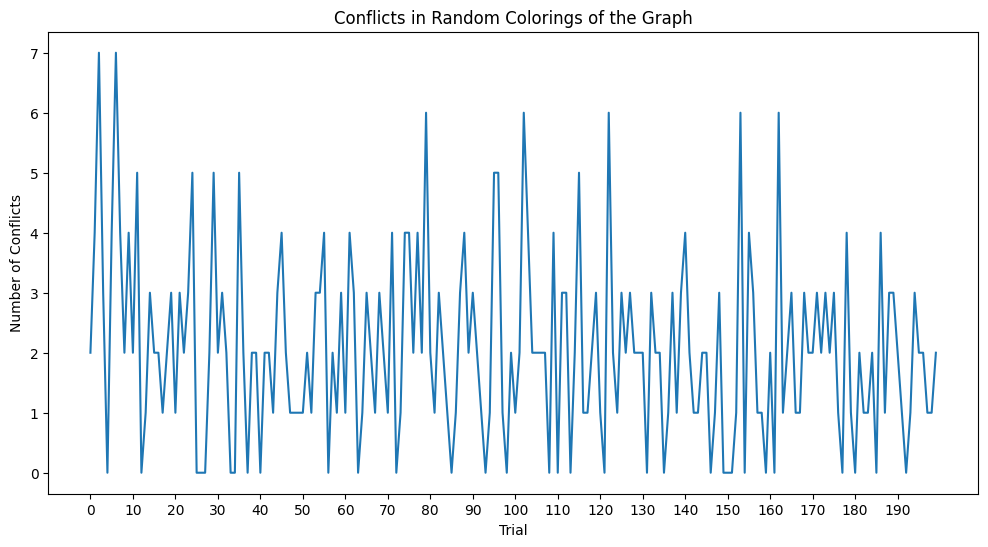

Average conflicts: 2.06


In [65]:

list_of_conflicts = []
for i in range(200):
    multiple_coloring = random_coloring(G)
    node_colors = [coloring[node] for node in G.nodes()]
    conflicts = coloring_conflicts(G, multiple_coloring)
    list_of_conflicts.append(conflicts)
    print(f"Trial {i+1}: Number of conflicts: {conflicts}")


plt.figure(figsize=(12, 6))
plt.plot(list_of_conflicts)
plt.xlabel('Trial')
plt.ylabel('Number of Conflicts')
plt.title('Conflicts in Random Colorings of the Graph')
plt.xticks(range(0, 200, 10))

plt.show()

print(f"Average conflicts: {np.mean(list_of_conflicts):.2f}")


An average number of conflicts of 1.55 / 30 possible is really good odds for a random assignment of colors

For 100 trials : Average Number of conflicts: 2.13
For 200 trials : Average Number of conflicts: 1.90
For 300 trials : Average Number of conflicts: 2.02
For 400 trials : Average Number of conflicts: 2.04
For 500 trials : Average Number of conflicts: 2.02
For 600 trials : Average Number of conflicts: 2.06
For 700 trials : Average Number of conflicts: 1.99
For 800 trials : Average Number of conflicts: 1.90
For 900 trials : Average Number of conflicts: 2.04
For 1000 trials : Average Number of conflicts: 1.98


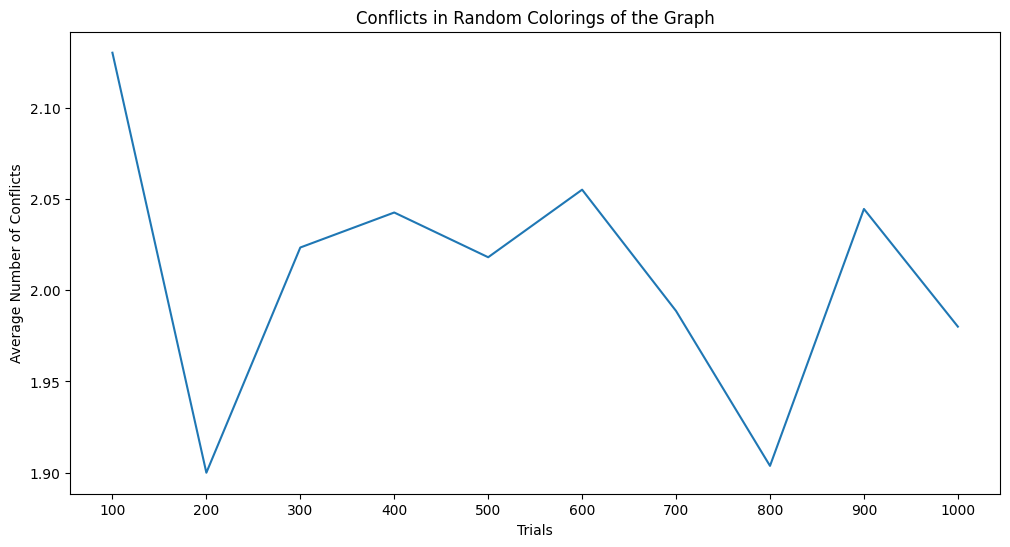

In [66]:
average_conflicts = []
trials = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
for i in range(len(trials)):
    list_of_conflicts = []
    for j in range(trials[i]):
        multiple_coloring = random_coloring(G)
        node_colors = [coloring[node] for node in G.nodes()]
        conflicts = coloring_conflicts(G, multiple_coloring)
        list_of_conflicts.append(conflicts)
    average_conflicts.append(np.mean(list_of_conflicts))
    print(f"For {trials[i]} trials : Average Number of conflicts: {average_conflicts[-1]:.2f}")


plt.figure(figsize=(12, 6))
plt.plot(trials, average_conflicts)
plt.xlabel('Trials')
plt.ylabel('Average Number of Conflicts')
plt.title('Conflicts in Random Colorings of the Graph')
plt.xticks(trials)

plt.show()
